<a href="https://colab.research.google.com/github/UsmanArif169/Machine-Learning-Algorithms-/blob/main/_linear_regression_assumptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/data.csv')
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [4]:
X = df.drop(columns = ['target'])
y = df['target']

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = lr.predict(X_test)

In [8]:
residual = y_test - y_pred

In [9]:
residual

,target
95,-12.946858
15,-17.217711
30,1.766695
158,-26.558474
128,24.478078
115,0.361432
69,-18.989699
170,-29.273016
174,-4.818961
45,-4.710372


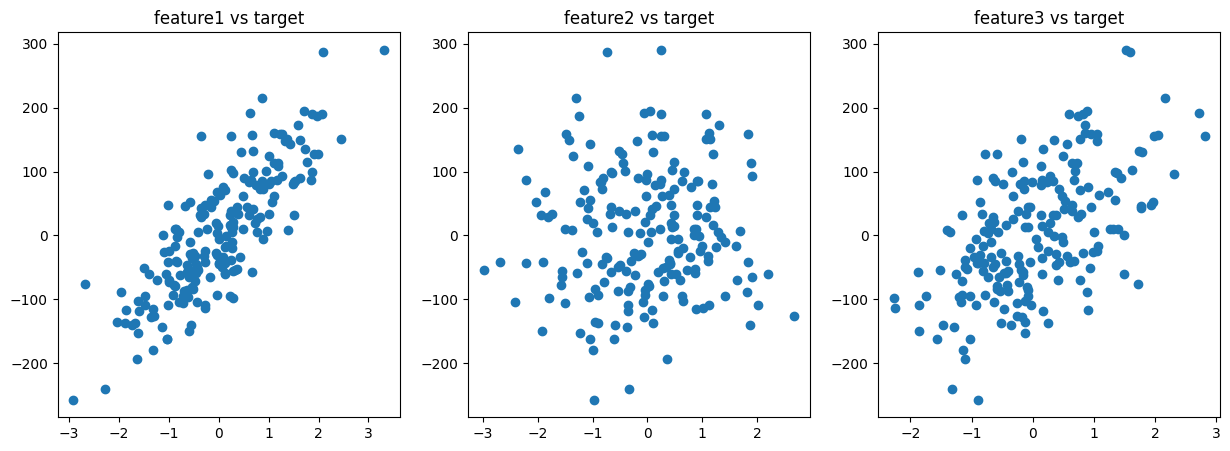

In [22]:
# Assumptions
# There are five assumptions.

# 1. Linear Relationship

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(15,5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title('feature1 vs target')

ax2.scatter(df['feature2'], df['target'])
ax2.set_title('feature2 vs target')

ax3.scatter(df['feature3'], df['target'])
ax3.set_title('feature3 vs target')

plt.show()

In [11]:
# 2. Multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

vlf = []
for i in range(X_train.shape[1]):
  vlf.append(variance_inflation_factor(X_train, i))

vlf

[np.float64(1.0019497109290072),
 np.float64(1.0112734765863598),
 np.float64(1.0112111183384132)]

In [12]:
pd.DataFrame({'vlf': vlf}, index = df.columns[0:3]). T

,feature1,feature2,feature3
vlf,1.00195,1.011273,1.011211


<Axes: >

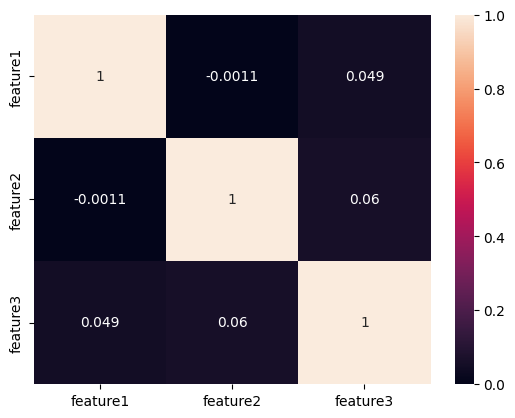

In [14]:
# Another techinque

sns.heatmap(df.iloc[:, 0:3] .corr(), annot = True)

/tmp/ipykernel_1455/1836861126.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual, kde = True)


<Axes: xlabel='target', ylabel='Density'>

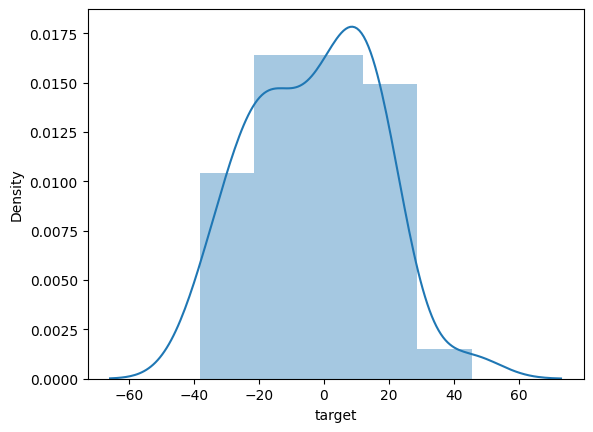

In [16]:
# 3. Normality of Residual

sns.distplot(residual, kde = True)

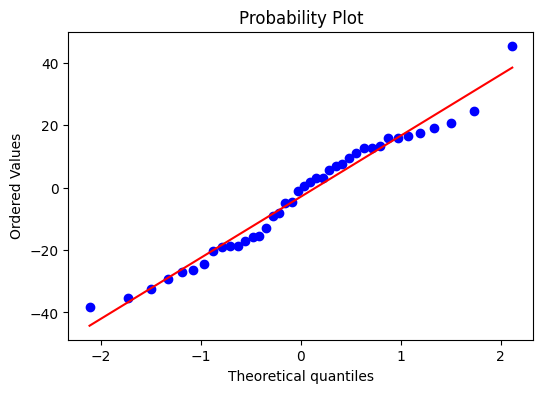

In [17]:
# Another method

# QQ Plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

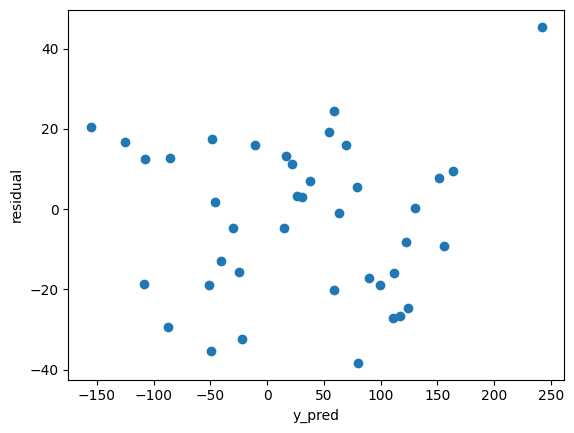

In [19]:
# 4. Homoscedasticity  (homogenious spread)

plt.scatter(y_pred, residual)
plt.xlabel('y_pred')
plt.ylabel('residual')
plt.show()

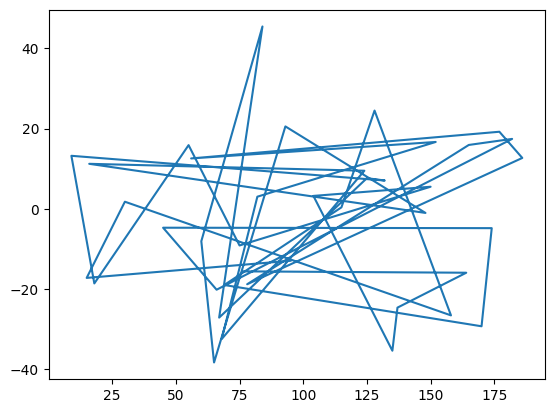

In [21]:
# 5. Autocorrelation of Residuals  (No regular pattern)

plt.plot (residual)